## About This Analysis

This notebook is part of a RetailRocket e-commerce funnel analysis covering 1,404,179 unique users. The 50 items were selected using two thresholds — views above the 95th percentile and a cart rate below 2.68%. For the complete SQL analysis visit the full repository: https://github.com/Roshan-1510/retailrocket-funnel-analysis.


In [1]:
top_50_ids=[187946,
5411,
370653,
96924,
298009,
335975,
151444,
434782,
142466,
102306,
91755,
232509,
225778,
209994,
29100,
429094,
15948,
359491,
413166,
290250,
341482,
316779,
449571,
109618,
84160,
445749,
287664,
215715,
149275,
403757,
298196,
184998,
260650,
82389,
29890,
351044,
137144,
216888,
101845,
294482,
260317,
75779,
251349,
203908,
244924,
260539,
229204,
162525,
115323,
156173]

len(top_50_ids)


50

Upload the dataset files required for analysis (events and item properties).

In [2]:
import pandas as pd
df1 = pd.read_csv("/kaggle/input/datasets/retailrocket/ecommerce-dataset/item_properties_part1.csv")
df2 = pd.read_csv("/kaggle/input/datasets/retailrocket/ecommerce-dataset/item_properties_part2.csv")
df3 = pd.read_csv("/kaggle/input/datasets/retailrocket/ecommerce-dataset/events.csv")

Loaded datasets:
- df1, df2 → item properties (metadata)
- df3 → user interaction events

In [3]:
df1.shape

(10999999, 4)

In [4]:
df3.shape

(2756101, 5)

## Filtering Dataset for Selected Items

Extracting latest category (categoryid) for each selected item from item properties.

In [5]:
df = pd.concat([df1, df2], ignore_index=True)

df_filtered = df1[
    (df1['property'] == 'categoryid') &
    (df1['itemid'].isin(top_50_ids))
]

df_latest = df_filtered.sort_values('timestamp').drop_duplicates(
    subset=['itemid'], keep='last'
)
df_result=df_latest[['itemid', 'property', 'value']]

print(df_result.to_string(index=False))

 itemid   property value
 203908 categoryid  1558
 413166 categoryid   342
 187946 categoryid  1393
 215715 categoryid   926
 351044 categoryid  1663
 370653 categoryid    82
  84160 categoryid  1244
 298009 categoryid   529
 251349 categoryid   499
  75779 categoryid   167
 115323 categoryid  1325
 149275 categoryid  1526
   5411 categoryid   789
 109618 categoryid   921
 101845 categoryid   984
 260539 categoryid   124
 429094 categoryid   973
  29890 categoryid   167
 290250 categoryid   352
 316779 categoryid   491
  15948 categoryid   438
 216888 categoryid   429


In [6]:
result_ids = set(df_latest['itemid'])

input_ids = set(top_50_ids)

missing_ids = input_ids - result_ids

print(len(missing_ids), sorted(missing_ids))

28 [29100, 82389, 91755, 96924, 102306, 137144, 142466, 151444, 156173, 162525, 184998, 209994, 225778, 229204, 232509, 244924, 260317, 260650, 287664, 294482, 298196, 335975, 341482, 359491, 403757, 434782, 445749, 449571]


9 items do not have category metadata. These represent data quality issues and cannot be used for category-level analysis.

In [7]:
top_9_ids=[29100, 156173, 184998, 229204, 244924, 260650, 287664, 298196, 449571]

In [8]:
df_all = pd.concat([df1], ignore_index=True)

check = df_all[df_all['itemid'].isin(top_9_ids)]

len(check)

0

Validation confirms that these 9 items are completely missing from item properties, reinforcing that they lack metadata.

In [9]:
valid_ids = list(set(top_50_ids) - set(top_9_ids))

df_valid = df3[df3['itemid'].isin(valid_ids)]

Filtered dataset to 41 valid items that have category metadata.  
Subsequent analysis focuses only on these items.

## Category Level Analysis

In [10]:
df_props = pd.concat([df1], ignore_index=True)

df_cat = df_props[
    (df_props['property'] == 'categoryid') &
    (df_props['itemid'].isin(valid_ids))
]

df_cat_latest = df_cat.sort_values(by='timestamp').drop_duplicates(
    subset=['itemid'], keep='last'
)

df_cat_latest = df_cat_latest[['itemid', 'value']].rename(
    columns={'value': 'categoryid'}
)

In [11]:
item_stats = df_valid.groupby(['itemid','event']).size().unstack(fill_value=0)

item_stats = item_stats.rename(columns={
    'view': 'views',
    'addtocart': 'carts',
    'transaction': 'transactions'
}).reset_index()

In [12]:
df_valid_cat = item_stats.merge(df_cat_latest, on='itemid', how='left')

In [13]:
category_stats = df_valid_cat.groupby('categoryid').agg(
    item_count=('itemid', 'count'),
    total_views=('views', 'sum'),
    total_carts=('carts', 'sum')
).reset_index()

category_stats['cart_rate'] = category_stats['total_carts'] / category_stats['total_views']

category_stats.sort_values('cart_rate')

,categoryid,item_count,total_views,total_carts,cart_rate
0,124,1,574,0,0.000000
7,167,2,972,0,0.000000
5,1558,1,452,0,0.000000
4,1526,1,604,0,0.000000
11,438,1,711,0,0.000000
10,429,1,485,0,0.000000
9,352,1,634,0,0.000000
8,342,1,670,0,0.000000
12,491,1,605,0,0.000000
13,499,1,457,0,0.000000


In [14]:
df_cat_1188 = df_valid_cat[df_valid_cat['categoryid'] == 1188]
df_cat_1188

,itemid,carts,transactions,views,categoryid


In [15]:
category_stats = df_valid_cat.groupby('categoryid').agg(
    item_count=('itemid', 'count'),
    total_views=('views', 'sum'),
    total_carts=('carts', 'sum')
).reset_index()

category_stats['cart_rate'] = category_stats['total_carts'] / category_stats['total_views']

In [16]:
category_stats = category_stats.sort_values('cart_rate')
print(category_stats.to_string(index=False))

categoryid  item_count  total_views  total_carts  cart_rate
       124           1          574            0   0.000000
       167           2          972            0   0.000000
      1558           1          452            0   0.000000
      1526           1          604            0   0.000000
       438           1          711            0   0.000000
       429           1          485            0   0.000000
       352           1          634            0   0.000000
       342           1          670            0   0.000000
       491           1          605            0   0.000000
       499           1          457            0   0.000000
       529           1         1642            0   0.000000
       984           1          461            0   0.000000
       973           1          727            0   0.000000
       926           1          637            0   0.000000
       921           1          764            0   0.000000
        82           1         1854     

In [17]:
broken = category_stats[category_stats['cart_rate'] == 0]

weak = category_stats[
    (category_stats['cart_rate'] > 0) &
    (category_stats['cart_rate'] < 0.005)
]

best = category_stats[category_stats['cart_rate'] >= 0.005]

In [18]:
broken[broken['item_count'] >= 2]

,categoryid,item_count,total_views,total_carts,cart_rate
7,167,2,972,0,0.0


In [19]:
total_views = category_stats['total_views'].sum()
broken_views = broken['total_views'].sum()

impact = broken_views / total_views

print(round(impact,4))

0.6123


In [20]:
best.sort_values('cart_rate', ascending=False)

,categoryid,item_count,total_views,total_carts,cart_rate
1,1244,1,856,6,0.007009


In [21]:
print(category_stats['cart_rate'].describe())

count    21.000000
mean      0.000854
std       0.001904
min       0.000000
25%       0.000000
50%       0.000000
75%       0.000000
max       0.007009
Name: cart_rate, dtype: float64


In [22]:
q75 = category_stats['cart_rate'].quantile(0.75)
q50 = category_stats['cart_rate'].quantile(0.50)

high = category_stats[category_stats['cart_rate'] >= q75]
mid  = category_stats[(category_stats['cart_rate'] >= q50) & (category_stats['cart_rate'] < q75)]
low  = category_stats[category_stats['cart_rate'] < q50]

In [23]:
top_categories = category_stats.sort_values('cart_rate', ascending=False).head(5)

top_categories

,categoryid,item_count,total_views,total_carts,cart_rate
1,1244,1,856,6,0.007009
6,1663,1,690,3,0.004348
15,789,1,2325,9,0.003871
2,1325,1,474,1,0.002110
3,1393,1,3410,2,0.000587


These represent the highest-performing categories within a generally low-conversion environment.
Even the best categories show very low conversion rates, reinforcing that the issue is systemic rather than isolated.

##User Level Analysis

In [24]:
df_ui = df3[df3['itemid'].isin(valid_ids)]

user_item = df_ui.groupby(['visitorid', 'itemid', 'event']).size().unstack(fill_value=0).reset_index()

user_item = user_item.rename(columns={
    'view': 'views',
    'addtocart': 'carts',
    'transaction': 'transactions'
})

for col in ['views', 'carts', 'transactions']:
    if col not in user_item:
        user_item[col] = 0

In [25]:
repeat_view = user_item[user_item['views'] >= 3]
len(repeat_view)

985

In [26]:
# never add to cart
no_cart = user_item[user_item['carts'] == 0]

# repeat viewers with no cart
high_intent_no_action = user_item[
    (user_item['views'] >= 3) & (user_item['carts'] == 0)
]

# converters
converters = user_item[user_item['carts'] > 0]

In [27]:
len(user_item), len(no_cart), len(high_intent_no_action), len(converters)

(30409, 30382, 978, 27)

The majority of user-item interactions do not progress beyond viewing.  
A very small fraction converts, and only a limited subset shows repeated engagement without action.

In [28]:
ratio = len(high_intent_no_action) / len(user_item)

f"{ratio:.2%}"

'3.22%'

Only a small proportion of users repeatedly view items without taking action, indicating that delayed decision-making or price-waiting behavior is not a primary driver of low conversion.

In [29]:
df_ui['timestamp'] = pd.to_datetime(df_ui['timestamp'], unit='ms')

time_span = df_ui.groupby(['visitorid','itemid'])['timestamp'].agg(['min','max'])

time_span['days_diff'] = (time_span['max'] - time_span['min']).dt.days

time_span['days_diff'].describe()

/tmp/ipykernel_16/2695848047.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_ui['timestamp'] = pd.to_datetime(df_ui['timestamp'], unit='ms')


count    30409.000000
mean         0.312473
std          3.560111
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max        129.000000
Name: days_diff, dtype: float64

In [30]:
repeat_long_gap = time_span[time_span['days_diff'] >= 3].reset_index()

merged = repeat_long_gap.merge(user_item, on=['visitorid','itemid'])

waiting_users = merged[merged['carts'] == 0]

len(waiting_users)

495

In [31]:
zero_conversion = item_stats[
    (item_stats['views'] > 0) &
    (item_stats['carts'] == 0)
]
len(zero_conversion)

34

In [32]:
threshold = item_stats['views'].quantile(0.95)

high_view_zero = zero_conversion[
    zero_conversion['views'] >= threshold
]

In [33]:
high_view_zero = high_view_zero.sort_values(by='views', ascending=False)

high_view_zero

event,itemid,carts,transactions,views
35,370653,0,0,1854


These are extreme failure cases where items receive high visibility but generate zero user action, representing the strongest contributors to conversion loss.

In [34]:
threshold = item_stats['views'].quantile(0.90)

# Calculate cart_rate for item_stats
item_stats['cart_rate'] = item_stats['carts'] / item_stats['views']
item_stats['cart_rate'] = item_stats['cart_rate'].fillna(0) # Handle potential division by zero

problem_items = item_stats[
    (item_stats['views'] >= threshold) &
    (item_stats['cart_rate'] < 0.005)
]

problem_items.sort_values('views', ascending=False)

event,itemid,carts,transactions,views,cart_rate
17,187946,2,0,3410,0.000587
0,5411,9,0,2325,0.003871
35,370653,0,0,1854,0.000000
29,298009,0,0,1642,0.000000
7,96924,0,0,1633,0.000000


These items receive high user attention but show near-zero conversion, indicating a breakdown at the evaluation stage rather than lack of demand.

In [35]:
df3[df3['itemid'] == 370653]['event'].value_counts()

event
view    1854
Name: count, dtype: int64

In [36]:
df3[df3['itemid'] == 84160]['event'].value_counts()

event
view           856
addtocart        6
transaction      5
Name: count, dtype: int64

Comparison shows that some items trigger user actions while others receive only views, confirming that conversion depends on crossing a decision threshold rather than traffic volume.

In [37]:
problem_categories = category_stats[category_stats['cart_rate'] < 0.005]

In [38]:
print("Distribution of item counts per category:")
print(category_stats['item_count'].value_counts().sort_index())

Distribution of item counts per category:
item_count
1    20
2     1
Name: count, dtype: int64


In [39]:
items_with_categoryid = set(df_cat_latest['itemid'])
valid_items_without_categoryid = set(valid_ids) - items_with_categoryid

print(f"Items in valid_ids that DO NOT have a categoryid ({len(valid_items_without_categoryid)} items):")
print(sorted(list(valid_items_without_categoryid)))

Items in valid_ids that DO NOT have a categoryid (19 items):
[82389, 91755, 96924, 102306, 137144, 142466, 151444, 162525, 209994, 225778, 232509, 260317, 294482, 335975, 341482, 359491, 403757, 434782, 445749]


These are the 19 items that are part of our `valid_ids` but do not have a `categoryid` property recorded in the `item_properties` dataset. This is why they are excluded from the category-level performance analysis, even though they are considered 'valid' in other contexts.

# Visualization



### Overall Conversion Funnel

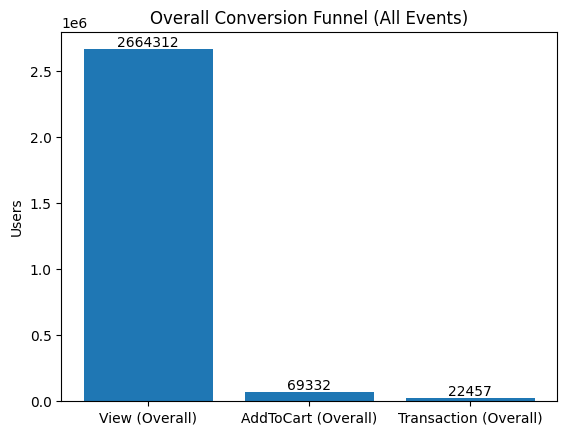

In [40]:
import matplotlib.pyplot as plt

total_views_overall = df3[df3['event'] == 'view'].shape[0]
total_carts_overall = df3[df3['event'] == 'addtocart'].shape[0]
total_transactions_overall = df3[df3['event'] == 'transaction'].shape[0]

stages_overall = ['View (Overall)', 'AddToCart (Overall)', 'Transaction (Overall)']
values_overall = [total_views_overall, total_carts_overall, total_transactions_overall]

plt.figure()
bars_overall = plt.bar(stages_overall, values_overall)
plt.title("Overall Conversion Funnel (All Events)")
plt.ylabel("Users")

# Add labels to the bars
for bar in bars_overall:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.05, round(yval, 2), ha='center', va='bottom')

plt.show()

The funnel shows a sharp drop from View to AddToCart, indicating that the primary conversion failure occurs at the first decision stage.

While a significant number of users view items, only a very small fraction proceed to add them to cart, confirming that the issue lies in converting interest into action rather than driving traffic.

Views vs Cart Rate

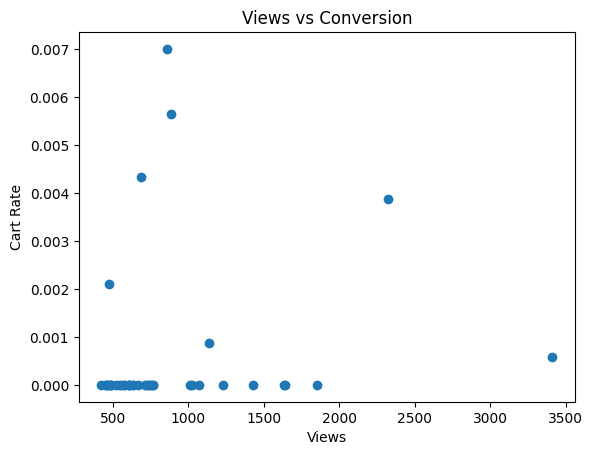

In [41]:
plt.figure()
plt.scatter(item_stats['views'], item_stats['cart_rate'])
plt.xlabel("Views")
plt.ylabel("Cart Rate")
plt.title("Views vs Conversion")
plt.show()

The scatter plot shows that items with high views are concentrated near zero conversion rates.

This indicates that increased visibility does not lead to higher conversion, confirming that the issue lies in the product evaluation stage rather than user interest or traffic.

A large cluster of high-view items with near-zero conversion highlights systemic inefficiency in converting user attention into action.

Category-Level Performance

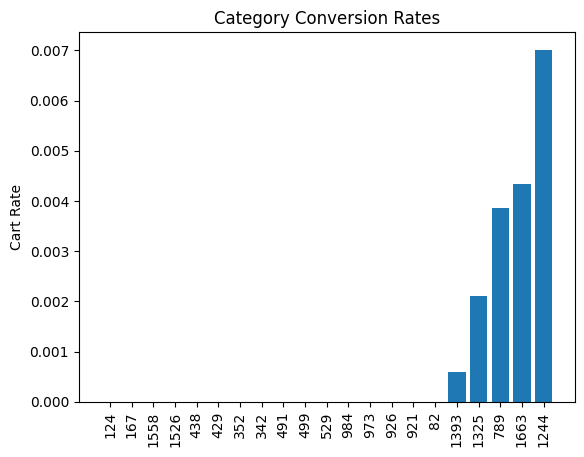

In [42]:
plt.figure()
plt.bar(category_stats['categoryid'].astype(str), category_stats['cart_rate'])
plt.xticks(rotation=90)
plt.title("Category Conversion Rates")
plt.ylabel("Cart Rate")
plt.show()

Most categories show near-zero conversion rates, with only a few categories exhibiting slightly higher performance.

This indicates that conversion failure is not isolated to specific items but is clustered at the category level, suggesting broader issues in product presentation or category-level user experience.

Even the highest-performing categories remain significantly below typical conversion benchmarks, reinforcing that the problem is systemic rather than localized.

Distribution of Cart Rate

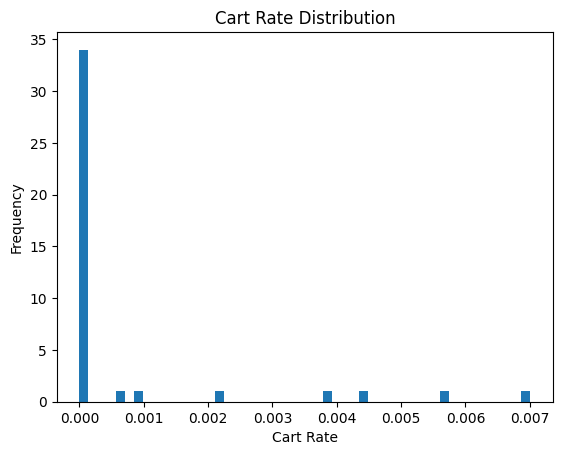

In [43]:
plt.figure()
plt.hist(item_stats['cart_rate'], bins=50)
plt.title("Cart Rate Distribution")
plt.xlabel("Cart Rate")
plt.ylabel("Frequency")
plt.show()

The distribution is heavily concentrated near zero, indicating that the majority of items have extremely low or no conversion.

This confirms that poor conversion is not limited to a few outliers but is widespread across most items.

Only a very small number of items achieve even marginal conversion, highlighting a systemic inability to convert user interest into action.

Top failure items

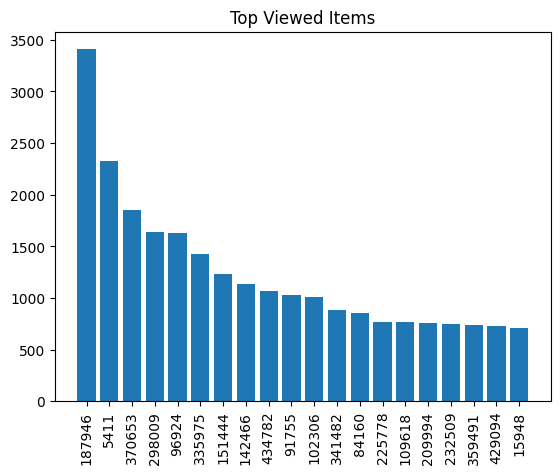

In [44]:
top_fail = item_stats.sort_values('views', ascending=False).head(20)

plt.figure()
plt.bar(top_fail['itemid'].astype(str), top_fail['views'])
plt.xticks(rotation=90)
plt.title("Top Viewed Items")
plt.show()

These items attract the highest user attention, yet many of them exhibit little to no conversion.

This highlights that high visibility alone does not translate into user action, reinforcing the gap between interest and purchase intent.

Several of these high-traffic items belong to the previously identified low-conversion segment, showing that they disproportionately contribute to the overall conversion drop.

## Final Conclusion

- The primary drop in the funnel occurs at the View → AddToCart stage, not at later steps.

- High user activity (views) does not translate into action, indicating a failure in converting interest into intent.

- A significant portion of traffic is concentrated on items with near-zero conversion, which disproportionately lowers overall performance.

- Conversion failure is isolated to product level and scattered across 21 categories pointing towards product level issue not category level

- User behavior shows that most users do not revisit or reconsider items, confirming that the failure occurs at the first interaction rather than during delayed decision-making.

- Items with missing metadata further contribute to zero conversion, highlighting data quality issues.

### Final Insight

Users are willing to explore products, but most items fail to cross the minimum decision threshold required to trigger action, leading to immediate drop-off and low overall conversion.